In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('house.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df=df[['GarageQual','FireplaceQu','SalePrice']]
df.sample(5)

,GarageQual,FireplaceQu,SalePrice
843,NaN,NaN,141000
579,Fa,NaN,131500
318,TA,TA,260000
609,TA,NaN,118500
656,TA,NaN,145500


In [4]:
df.isnull().mean()*100

GarageQual      5.547945
FireplaceQu    47.260274
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

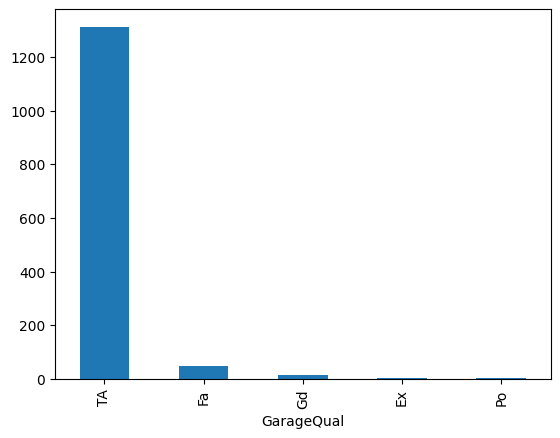

In [5]:
df['GarageQual'].value_counts().plot(kind='bar')

In GarageQual col, TA dominates the other values and is suitable to fill the n/a values

In [6]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

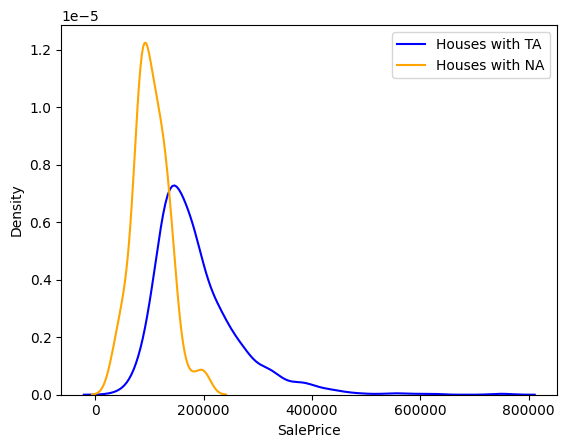

In [7]:
import seaborn as sns
fig,(ax1)=plt.subplots()
sns.kdeplot(df[df['GarageQual']=='TA']['SalePrice'],color='blue',ax=ax1,label='Houses with TA')
sns.kdeplot(df[df['GarageQual'].isnull()]['SalePrice'],color='orange',ax=ax1,label='Houses with NA')
plt.legend()
plt.show()

In [8]:
temp=df[df['GarageQual']=='TA']['SalePrice']

In [9]:
df['GarageQual']=df['GarageQual'].fillna('TA')

<Axes: xlabel='GarageQual'>

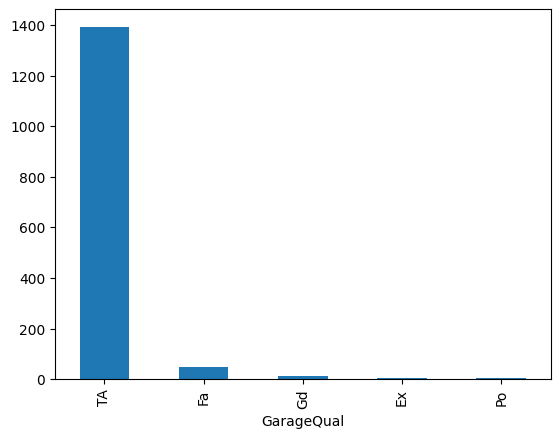

In [10]:
df['GarageQual'].value_counts().plot(kind='bar')

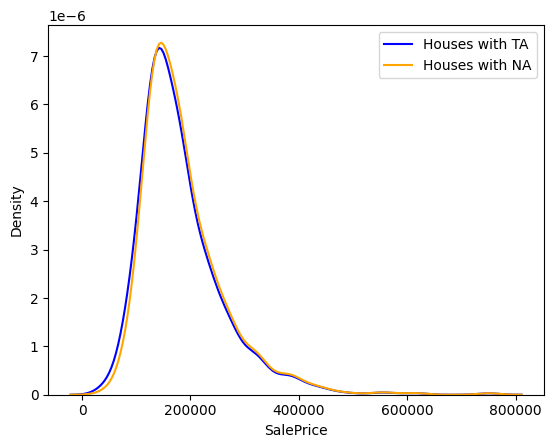

In [11]:
fig,(ax1)=plt.subplots()
sns.kdeplot(df[df['GarageQual']=='TA']['SalePrice'],color='blue',ax=ax1,label='Houses with TA')
sns.kdeplot(temp,color='orange',ax=ax1,label='Houses with NA')
plt.legend()
plt.show()

<Axes: xlabel='FireplaceQu'>

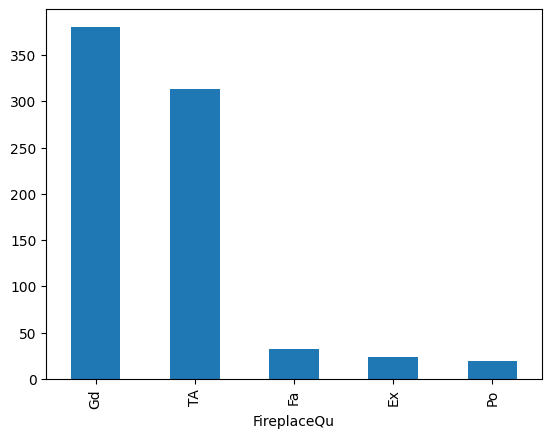

In [12]:
df['FireplaceQu'].value_counts().plot(kind='bar')

Here, Gd and TA are almost equal

In [13]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

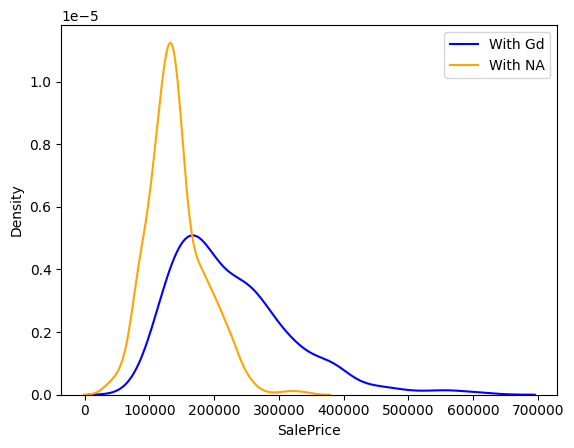

In [14]:
fig,(ax1)=plt.subplots()
sns.kdeplot(df[df['FireplaceQu']=='Gd']['SalePrice'],color='blue',ax=ax1,label='With Gd')
sns.kdeplot(df[df['FireplaceQu'].isnull()]['SalePrice'],color='orange',ax=ax1,label='With NA')
plt.legend()
plt.show()

In [15]:
temp=df[df['FireplaceQu']=='Gd']['SalePrice']
temp

3       140000
6       307000
11      345000
13      279500
20      325300
         ...  
1437    394617
1440    191000
1443    121000
1451    287090
1457    266500
Name: SalePrice, Length: 380, dtype: int64

In [16]:
df['FireplaceQu']=df['FireplaceQu'].fillna('Gd')

<Axes: xlabel='FireplaceQu'>

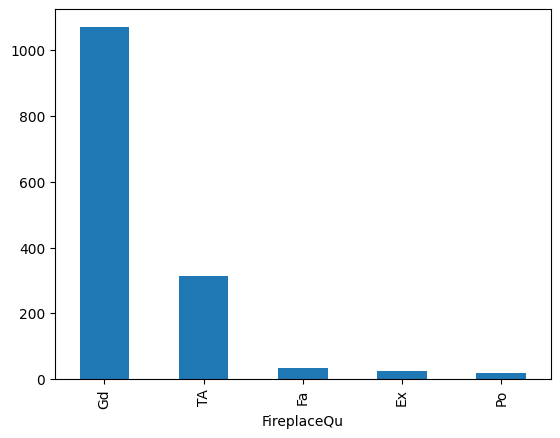

In [17]:
df['FireplaceQu'].value_counts().plot(kind='bar')

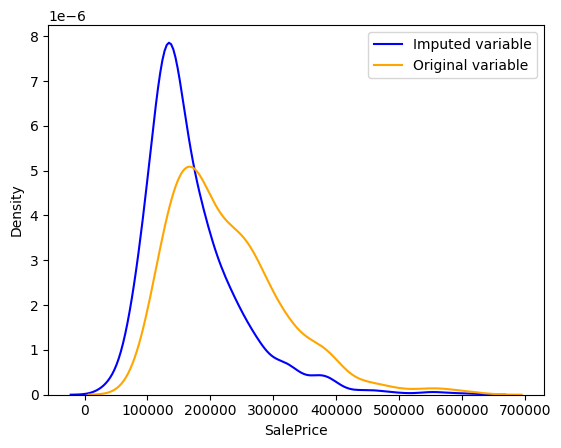

In [18]:
fig,(ax1)=plt.subplots()
sns.kdeplot(df[df['FireplaceQu']=='Gd']['SalePrice'],color='blue',ax=ax1,label='Imputed variable')
sns.kdeplot(temp,color='orange',ax=ax1,label='Original variable')
plt.legend()
plt.show()

<h3><b>Using sklearn

In [19]:
from sklearn.impute import SimpleImputer

imputer=SimpleImputer(strategy='most_frequent')

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)
X_train=imputer.fit_transform(X_train)
X_test=imputer.transform(X_test)

imputer.statistics_

array(['TA', 'Gd'], dtype=object)